# Introduction to Reinforcement Learning — Live Demo (Part 2)
### A tiny RLHF-style demo with `trl`'s `GRPOTrainer`

This is the payoff of the talk: the **same core loop** (agent, action, reward, learn)
that trained the GridWorld agent and the LunarLander agent is what shapes the behavior
of language models — this is the mechanism behind RLHF and behind reasoning models.

We use **GRPO** (Group Relative Policy Optimization — the algorithm behind DeepSeek-R1),
because unlike classic RLHF/PPO it needs **no separate reward model**: you just write a
plain Python function that scores completions.

**The demo:** we reward the model for (a) including *any* emoji, with a big bonus for
the unicorn emoji 🦄 specifically, and (b) keeping its answer around ~20 words. Watch the
model's style visibly shift toward unicorns after a short training run.

> Requires a GPU runtime (Runtime → Change runtime type → T4 GPU). Training is kept to
> a small number of steps so it finishes in a few minutes for a live demo — this is a
> **style-shaping** demo, not a fully converged fine-tune.


In [15]:
import os
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("checkpoints/grpo_unicorn_demo", exist_ok=True)
print("checkpoints/ folder ready")


checkpoints/ folder ready


In [16]:
import re
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"   # small enough to fine-tune live on a single GPU

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [17]:
def generate(model, tokenizer, prompt, max_new_tokens=40):
    """Greedy-ish sampling from a chat-tuned small model."""
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)
    output = model.generate(
        inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.8,
        pad_token_id=tokenizer.pad_token_id
    )
    return tokenizer.decode(output[0][inputs.shape[1]:], skip_special_tokens=True)


demo_prompts = [
    "Do you like unicorns?"
    "Tell me about your favorite mythical creature.",
    "Describe a magical creature you'd love to meet.",
    "Show me the unicorn emoji",
    "Output only the unicorn emoji: 🦄",
    "output the horse emoji only",
    "What's your favorite hobby?",   # kept neutral on purpose, as a control
]


In [28]:
# --- Baseline: what does the model say BEFORE any reward shaping? ---

base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(device)

baseline_outputs = {}
for p in demo_prompts:
    baseline_outputs[p] = generate(base_model, tokenizer, p)
    print("PROMPT:", p)
    print("OUTPUT:", baseline_outputs[p])

# free memory before GRPOTrainer loads its own copy of the model
del base_model

if device == "cuda":
    torch.cuda.empty_cache()


PROMPT: Do you like unicorns?Tell me about your favorite mythical creature.
OUTPUT: As an AI language model, I don't have personal preferences or emotions, so I don't have the capacity to like anything, including unicorns. However, I can provide information and insights on various
PROMPT: Describe a magical creature you'd love to meet.
OUTPUT: As an AI language model, I don't have personal preferences or emotions like humans do, but I can tell you about a fictional creature that many people might enjoy meeting - the dragon.

A dragon is
PROMPT: Show me the unicorn emoji
OUTPUT: I'm sorry for any misunderstanding, but I'm not able to display or create images. However, you can easily make your own unicorn emoji using an image editor like Canva, Photoshop, or even
PROMPT: Output only the unicorn emoji: 🦄
OUTPUT: 👍❤️
PROMPT: output the horse emoji only
OUTPUT: 👋🚀
PROMPT: What's your favorite hobby?
OUTPUT: As an artificial intelligence language model, I don't have personal preferences or h

### The reward function

This is the whole "reward model" for this demo: a few lines of plain Python.
No labeled preference data, no separate reward network — just a rule we chose:
**any emoji gets a small reward, but the unicorn emoji 🦄 gets a much bigger one.**
This is exactly the kind of thing you'd swap out for "did the code run", "was the
answer factually correct", "did the agent complete the task", etc. in a real system —
here we picked something silly and visual on purpose, so the shift is obvious live.


In [29]:
EMOJI_PATTERN = re.compile(
    "[" 
    "\U0001F300-\U0001FAFF"   # symbols & pictographs, supplemental symbols
    "\U00002600-\U000027BF"   # misc symbols, dingbats
    "]",
    flags=re.UNICODE,
)

TEXT_TARGETS = {
    "unicorn": 2.0,
    "dragon":  0.8,
    "castle":  0.4,
    "tower":   0.4,
    "mythic":  0.4,
    "magic":   0.8,
}

UNICORN_EMOJI = "\U0001F984"   # 🦄
HORSE_EMOJIS  = ("\U0001F434", "\U0001F40E")  # 🐴 🐎
TARGET_WORD_COUNT = 20          # the length we're nudging answers toward

def reward_unicorn_emoji_and_length(completions, **kwargs):
    """Reward completions that contain an emoji (small reward), with a much
    bigger bonus specifically for the unicorn emoji, plus a length shaping term
    that nudges answers toward TARGET_WORD_COUNT words. Returns one float per
    completion."""
    rewards = []
    for text in completions:
        has_unicorn = UNICORN_EMOJI in text
        has_any_emoji = bool(EMOJI_PATTERN.search(text))
        word_count = len(text.split())
        length_penalty = -abs(word_count - TARGET_WORD_COUNT) * 0.02

        # checks all text targets
        text_reward = sum(v for k, v in TEXT_TARGETS.items() if k in text)

        if has_unicorn:
            emoji_reward = 5.0
        elif any(e in text for e in HORSE_EMOJIS):
            emoji_reward = 1.5
        elif has_any_emoji:
            emoji_reward = 1.0
        else:
            emoji_reward = -0.1

        rewards.append(emoji_reward + length_penalty + text_reward)
    return rewards


# quick sanity check on the reward function itself
print(reward_unicorn_emoji_and_length([
    "Sure! I had a magical day with a unicorn. 🦄 It was sparkly and fun overall.",
    "Sure! I had a great day. 😀 It was sunny and relaxing overall.",
    "I like magic everywhere all the time, yeaaaaaah",
    "I do not have feelings or a day to speak of, technically, as an AI."
]))


[7.72, 0.86, 0.4600000000000001, -0.2]


In [30]:
# --- Tiny training set: prompts skewed toward things that make unicorns an easy,
# natural answer, mixed with a few neutral prompts so the shift is visible by contrast ---

base_prompts = [
    "Tell me about your favorite mythical creature.",
    "Describe a magical creature you'd love to meet.",
    "What would you draw if you could draw anything magical?",
    "Tell me a bedtime story about a magical forest.",
    "What's the most whimsical animal you can think of?",
    "Describe a fantasy world you'd like to visit.",
    "What's your favorite hobby?",
    "Describe a sunny afternoon.",
    "What should I cook for dinner?",
    "Show me the unicorn emoji",
    "Output only the unicorn emoji: 🦄",
    "unicorn emoji: 🦄",
]

dataset = Dataset.from_dict({"prompt": base_prompts * 8})
print(f"Dataset size: {len(dataset)} prompts")


Dataset size: 96 prompts


In [31]:
from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    output_dir="checkpoints/grpo_unicorn_demo",
    per_device_train_batch_size=5,
    num_generations=5,          # completions sampled per prompt, compared within the group
    max_completion_length=40,
    learning_rate=1e-5,
    logging_steps=1,
    save_steps=10,
    max_steps=60,               
    report_to=[],
)

trainer = GRPOTrainer(
    model=MODEL_ID,
    reward_funcs=reward_unicorn_emoji_and_length,
    args=training_args,
    train_dataset=dataset,
)

trainer.train()


The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
/Users/ingy/Documents/GitHub/pyladies/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
1,0.000000
2,0.000000
3,-0.000000
4,-0.000000
5,0.000000
6,0.000000
7,-0.000000
8,0.000000
9,0.000000
10,-0.000000


TrainOutput(global_step=60, training_loss=6.836063359827449e-09, metrics={'train_runtime': 396.1574, 'train_samples_per_second': 0.757, 'train_steps_per_second': 0.151, 'total_flos': 0.0, 'train_loss': 6.836063359827449e-09, 'epoch': 0.625})

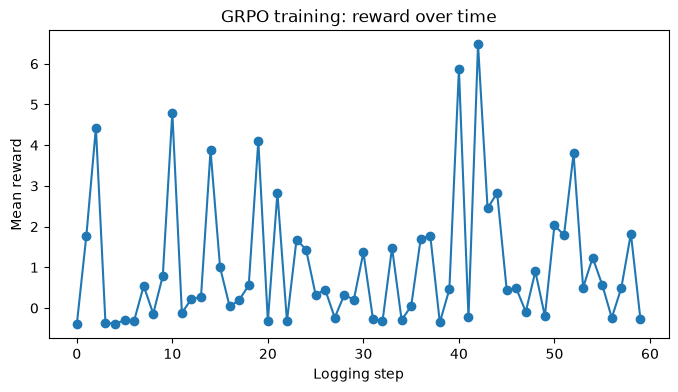

In [32]:
# --- Plot the reward curve ---
import matplotlib.pyplot as plt

reward_log = [log["reward"] for log in trainer.state.log_history if "reward" in log]

plt.figure(figsize=(8, 4))
plt.plot(reward_log, marker="o")
plt.xlabel("Logging step")
plt.ylabel("Mean reward")
plt.title("GRPO training: reward over time")
plt.show()


### Before & After

In [33]:
import textwrap

trained_model = AutoModelForCausalLM.from_pretrained(training_args.output_dir+"/checkpoint-40").to(device)

def show(label, text, width=90):
    wrapped = textwrap.fill(text.strip(), width=width, initial_indent="   ", subsequent_indent="   ")
    print(f"{label}:\n{wrapped}")

for p in demo_prompts:
    print("PROMPT:", p)
    show("BEFORE", baseline_outputs[p])
    show("AFTER ", generate(trained_model, tokenizer, p))
    print("-" * 60)


PROMPT: Do you like unicorns?Tell me about your favorite mythical creature.
BEFORE:
   As an AI language model, I don't have personal preferences or emotions, so I don't have
   the capacity to like anything, including unicorns. However, I can provide information
   and insights on various
AFTER :
   Sure! The unicorn is an iconic and magical creature, symbolizing purity, grace, and
   eternal love. Here's a detailed description of its most famous form:  The unicorn, also
   known as the white
------------------------------------------------------------
PROMPT: Describe a magical creature you'd love to meet.
BEFORE:
   As an AI language model, I don't have personal preferences or emotions like humans do,
   but I can tell you about a fictional creature that many people might enjoy meeting -
   the dragon.  A dragon is
AFTER :
   Sure! Here’s a magical creature:  - **Luna Luminara** (pronounced similar to
   "moonlight"), also known as Luna, is a mythical creature, and she was born in
-

### Recap

- We wrote a **reward function**, not a labeled dataset.
- In just a few minutes and ~40 training steps, the model's *style* visibly shifted
  toward unicorns 🦄 — because that's specifically what the reward rewarded most.
- **The bridge to reality:** production RLHF uses a much more nuanced reward (a
  learned reward model trained on human preference comparisons, or a verifiable signal
  like "did the code pass tests" for reasoning models) instead of "does it mention a
  unicorn" — but the training loop is exactly the same mechanism you just watched run.
- Checkpoints are saved in `checkpoints/grpo_unicorn_demo/` if you want to keep training
  or push the model to the Hugging Face Hub afterward.
